# Late Delivery Risk Prediction - Model Building

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Load Cleaned Dataset

In [5]:
df = pd.read_csv("../data/processed/DataCoSupplyChain_Clean.csv")

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastán,PENDING,NaN,1360,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastán,CLOSED,NaN,1360,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,NaN,1360,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,NaN,1360,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## Feature Selection

In [6]:
# Target variable
target = "Late_delivery_risk"

# Features
X = df.drop(columns=[target])

# Target
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (180519, 46)
Target shape: (180519,)


## Encode Categorical Features

In [7]:
# Find categorical columns
categorical_cols = X.select_dtypes(include=["object", "string"]).columns

print("Number of categorical columns:", len(categorical_cols))
print(categorical_cols)

Number of categorical columns: 19
Index(['Type', 'Delivery Status', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Segment', 'Customer State',
       'Customer Street', 'Department Name', 'Market', 'Order City',
       'Order Country', 'order date (DateOrders)', 'Order Region',
       'Order State', 'Order Status', 'Product Name',
       'shipping date (DateOrders)', 'Shipping Mode'],
      dtype='str')


In [8]:
# Encode categorical features
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in categorical_cols:
    X[col] = label_encoder.fit_transform(X[col].astype(str))

print("✅ Categorical columns encoded successfully!")

✅ Categorical columns encoded successfully!


In [9]:
X.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Category Id,Category Name,Customer City,Customer Country,...,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,1,3,4,91.250000,314.640015,0,73,40,66,1,...,475,2,NaN,1360,73,78,327.75,0,27149,3
1,3,5,4,-249.089996,311.359985,1,73,40,66,1,...,841,5,NaN,1360,73,78,327.75,0,2209,3
2,0,4,4,-247.779999,309.720001,3,73,40,452,0,...,841,1,NaN,1360,73,78,327.75,0,1980,3
3,1,3,4,22.860001,304.809998,0,73,40,285,0,...,835,2,NaN,1360,73,78,327.75,0,1752,3
4,2,2,4,134.210007,298.250000,0,73,40,66,1,...,835,6,NaN,1360,73,78,327.75,0,1528,3


## Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (144415, 46)
Testing Features: (36104, 46)
Training Target: (144415,)
Testing Target: (36104,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
# Remove columns with too many missing values
X = X.drop(columns=["Order Zipcode"])

# Fill the few missing Customer Zipcode values
X["Customer Zipcode"] = X["Customer Zipcode"].fillna(
    X["Customer Zipcode"].mode()[0]
)

print("✅ Missing values handled!")
print(X.isnull().sum().sum())

✅ Missing values handled!
0


## Train Logistic Regression Model

In [17]:
# Create the model
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
log_model.fit(X_train, y_train)

print("✅ Logistic Regression model trained successfully!")

✅ Logistic Regression model trained successfully!


d:\Late-Delivery-Risk-ML\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
# Make predictions
y_pred = log_model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5499944604475958

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.01      0.02     16308
           1       0.55      1.00      0.71     19796

    accuracy                           0.55     36104
   macro avg       0.60      0.50      0.36     36104
weighted avg       0.59      0.55      0.40     36104


Confusion Matrix:
[[  136 16172]
 [   75 19721]]


In [18]:
# Check missing values
missing = X.isnull().sum()

missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [19]:
print(X.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode']


In [20]:
# Remove columns with too many missing values
X = X.drop(columns=["Order Zipcode"])

# Fill the few missing Customer Zipcode values
X["Customer Zipcode"] = X["Customer Zipcode"].fillna(
    X["Customer Zipcode"].mode()[0]
)

print("✅ Missing values handled!")
print(X.isnull().sum().sum())

KeyError: "['Order Zipcode'] not found in axis"

In [21]:
missing = X.isnull().sum()
missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [22]:
print("NaN in X_train:", X_train.isnull().sum().sum())
print("NaN in X_test:", X_test.isnull().sum().sum())

NaN in X_train: 0
NaN in X_test: 0


In [23]:
log_model.fit(X_train, y_train)

d:\Late-Delivery-Risk-ML\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [25]:
log_model.fit(X_train, y_train)

d:\Late-Delivery-Risk-ML\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Predict on Test Data

In [29]:
# Predictions
y_pred = log_model.predict(X_test)

print(y_pred[:10])

[1 1 1 1 1 1 1 1 1 1]


## Model Evaluation

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5499944604475958


In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.01      0.02     16308
           1       0.55      1.00      0.71     19796

    accuracy                           0.55     36104
   macro avg       0.60      0.50      0.36     36104
weighted avg       0.59      0.55      0.40     36104



In [32]:
print(confusion_matrix(y_test, y_pred))

[[  136 16172]
 [   75 19721]]


# Step 8: Random Forest Classifier

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

print("✅ Random Forest trained successfully!")

✅ Random Forest trained successfully!


## Random Forest Prediction

In [34]:
# Predict
rf_pred = rf_model.predict(X_test)

## Random Forest Evaluation

In [35]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 1.0


In [36]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16308
           1       1.00      1.00      1.00     19796

    accuracy                           1.00     36104
   macro avg       1.00      1.00      1.00     36104
weighted avg       1.00      1.00      1.00     36104



In [37]:
print(confusion_matrix(y_test, rf_pred))

[[16308     0]
 [    0 19796]]


## Feature Importance

In [38]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
5,Delivery Status,0.438419
1,Days for shipping (real),0.301930
44,Shipping Mode,0.105776
2,Days for shipment (scheduled),0.102755
37,Order Status,0.030068
0,Type,0.003514
43,shipping date (DateOrders),0.001173
23,order date (DateOrders),0.001142
20,Order City,0.000997
13,Customer Street,0.000978


# Step 9: Decision Tree Classifier

In [39]:
from sklearn.tree import DecisionTreeClassifier

# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train
dt_model.fit(X_train, y_train)

print("✅ Decision Tree trained successfully!")

✅ Decision Tree trained successfully!


In [41]:
# Prediction
dt_pred = dt_model.predict(X_test)

In [42]:
print("Accuracy:", accuracy_score(y_test, dt_pred))

Accuracy: 1.0


In [43]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16308
           1       1.00      1.00      1.00     19796

    accuracy                           1.00     36104
   macro avg       1.00      1.00      1.00     36104
weighted avg       1.00      1.00      1.00     36104



In [44]:
print(confusion_matrix(y_test, dt_pred))

[[16308     0]
 [    0 19796]]


# Step 10: Model Comparison

In [45]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.549994
1,Decision Tree,1.000000
2,Random Forest,1.000000


In [46]:
comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,Decision Tree,1.000000
2,Random Forest,1.000000
0,Logistic Regression,0.549994


# Step 11: Save Best Model

In [47]:
import joblib

joblib.dump(rf_model, "../models/random_forest_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [48]:
import os

os.listdir("../models")

['random_forest_model.pkl']

# Model Comparison Summary

In [49]:
comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,Decision Tree,1.000000
2,Random Forest,1.000000
0,Logistic Regression,0.549994


# Top 15 Important Features

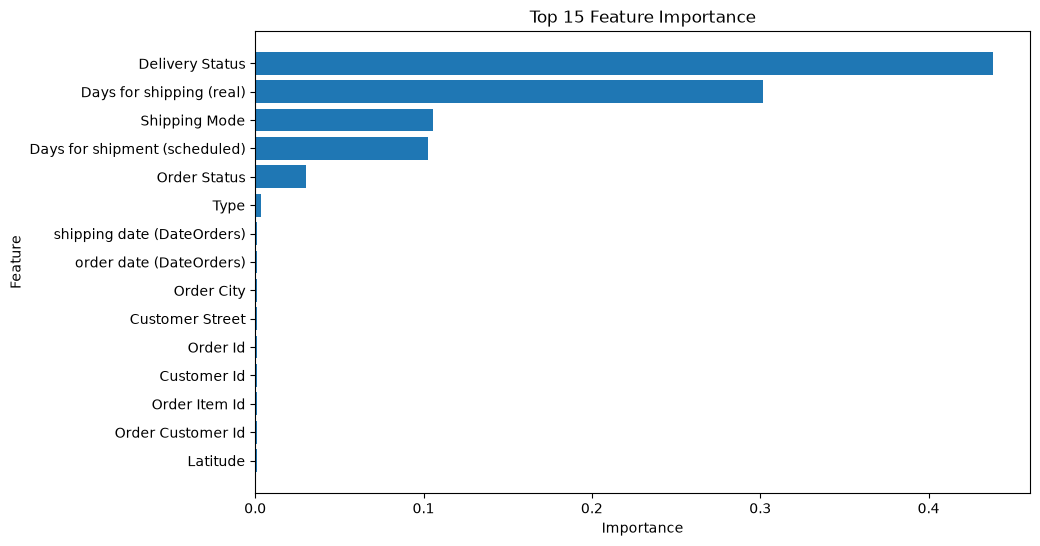

In [50]:
import matplotlib.pyplot as plt

importance = importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance")
plt.gca().invert_yaxis()
plt.show()